In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import torch
import gc
from pathlib import Path
import scanpy as sc

from models import *
from count_FM_function_v3 import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

device = cuda


# 1. Read Data

In [4]:
data_dir = Path("read_data/datasets/dentate_gyrus")
fp = next(data_dir.glob("*.h5ad"))
print("Loading:", fp)
adata = sc.read_h5ad(fp)
print(adata)

Loading: read_data/datasets/dentate_gyrus/DentateGyrus.h5ad
AnnData object with n_obs × n_vars = 2930 × 13913
    obs: 'age(days)', 'clusters', 'clusters_enlarged', 'index'
    var: 'index'
    obsm: 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


In [5]:
adata.obs

,age(days),clusters,clusters_enlarged,index
0,35,Granule immature,Granule-immature,AAACATACCCATGA
1,12,Radial Glia-like,Radial Glia-like,AAACATACCGTAGT
2,35,Granule mature,Granule-mature,AAACATACGAGAGC
3,12,Granule immature,Granule-immature,AAACATACTGAGGG
4,35,Granule immature,Granule-immature,AAACATTGGCATCA
...,...,...,...,...
2925,35,Granule immature,Granule-immature,TTTCTACTTCCCGT
2926,12,Neuroblast,Neuroblast 2,TTTGACTGCCTGTC
2927,35,Granule mature,Granule-mature,TTTGACTGTCTGGA
2928,35,Microglia,Microglia,TTTGCATGGGAGTG


In [6]:
np.unique(adata.obs['age(days)'])

array(['12', '35'], dtype=object)

In [7]:
np.unique(adata.obs['clusters'])

array(['Astrocytes', 'Cajal Retzius', 'Cck-Tox', 'Endothelial', 'GABA',
       'Granule immature', 'Granule mature', 'Microglia', 'Mossy',
       'Neuroblast', 'OL', 'OPC', 'Radial Glia-like', 'nIPC'],
      dtype=object)

In [8]:
adata.X.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

In [9]:
A = adata.X
M = adata.layers["matrix"]

if sp.issparse(A) and sp.issparse(M):
    same = (A != M).nnz == 0
else:
    same = np.array_equal(np.asarray(A), np.asarray(M))

print("adata.X == adata.layers['matrix'] ?", same)

adata.X == adata.layers['matrix'] ? True


# 2. Data Preperation

In [10]:
np.random.seed(123)
torch.manual_seed(123)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(123)

X_layer = adata.layers["matrix"] if "matrix" in adata.layers else adata.X

if sp.issparse(X_layer):
    X1_np = X_layer.toarray().astype(np.float32)
else:
    X1_np = np.asarray(X_layer, dtype=np.float32)

print("X1_np shape:", X1_np.shape, "dtype:", X1_np.dtype)
print("min/max:", float(X1_np.min()), float(X1_np.max()))
print("integer_like:", np.allclose(X1_np, np.round(X1_np)))
print("nonnegative:", bool((X1_np >= 0).all()))

X1_torch = torch.tensor(X1_np, dtype=torch.float32)  # keep CPU
N1, d = X1_torch.shape
print("N1, d =", N1, d)

X1_np shape: (2930, 13913) dtype: float32
min/max: 0.0 1718.0
integer_like: True
nonnegative: True
N1, d = 2930 13913


In [11]:
margin = 2
C_max = int(X1_np.max()) + margin
print("C_max =", C_max)
print("99.9% quantile count =", float(np.quantile(X1_np, 0.999)))

C_max = 1720
99.9% quantile count = 15.0


# 3. Model

In [12]:
separate_heads = False

net_base = ChunkedAdaLNTransformer(
    dim=d,
    out_dim=2*d,           # [lambda, beta]
    time_varying=True,
    d_model=256,           # appendix-like embedding size
    depth=8,               # appendix-like blocks
    n_heads=8,             # appendix-like heads
    mlp_ratio=4.0,
    dropout=0.0,
    chunk_size=128,        # makes it feasible for d=13913
).to(device)

In [13]:
nets = ChunkedAdaLNTransformer_rate(net_base).to(device)
n_params = sum(p.numel() for p in nets.parameters())

print("model params =", n_params)

model params = 9857792


# 4. Training

In [14]:
lr = 1e-3
optimizer = torch.optim.Adam(nets.parameters(), lr=lr)

batch_size = 32      # start small, increase if memory allows
num_epochs = 500     # start test run; later try 1000+
eps_t = 1e-4
eps_log = 1e-8
loss_mode = "poisson"

In [15]:
print("batch_size =", batch_size, "num_epochs =", num_epochs)

batch_size = 32 num_epochs = 500


In [16]:
nets.train()
nets, loss = CountFM_train(
    X1_torch=X1_torch,
    nets=nets,
    optimizer=optimizer,
    num_epochs=num_epochs,
    batch_size=batch_size,
    device=device,
    separate_heads=separate_heads,
    X0_torch=None,
    x0_mode="poisson",
    C_max=C_max,
    margin=margin,
    eps_t=eps_t,
    eps_log=eps_log,
    loss_mode=loss_mode,
)
print("final loss =", float(loss))

  0%|                                                   | 0/500 [00:00<?, ?it/s]/home/ganchao/miniconda3/envs/vfm/lib/python3.9/site-packages/torch/utils/_device.py:103: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  return func(*args, **kwargs)
  0%|                                           | 1/500 [00:01<15:21,  1.85s/it]

[CountFM][epoch 0] loss=2443.742188


 20%|████████▎                                | 101/500 [02:51<11:28,  1.73s/it]

[CountFM][epoch 100] loss=-991.453979


 40%|████████████████▍                        | 201/500 [05:43<08:41,  1.74s/it]

...

[CountFM][epoch 300] loss=-1141.335693


 80%|████████████████████████████████▉        | 401/500 [11:30<02:51,  1.73s/it]

[CountFM][epoch 400] loss=-1445.914185


100%|█████████████████████████████████████████| 500/500 [14:21<00:00,  1.72s/it]

final loss = 152.9398193359375


# 5. Generation

In [42]:
@torch.no_grad()
def sample_euler_batched_with_snaps(
    nets, n_step, x0_cpu, device,
    batch_eval=32, eps_t=1e-4, eps_log=1e-8, separate_heads=False,
    snap_ids=None, snap_n=0
):
    """
    Returns:
      x1_all: [N, d] long on CPU
      snaps: dict step -> [snap_n, d] float32 on CPU (only if snap_ids is not None and snap_n>0)
    """
    nets.eval()
    N, d = x0_cpu.shape

    if snap_ids is None or snap_n <= 0:
        snap_set = set()
        snap_ids = []
    else:
        snap_ids = sorted(set(int(s) for s in snap_ids))
        snap_set = set(snap_ids)

    snaps = {}
    if snap_set:
        for s in snap_ids:
            snaps[s] = torch.empty((snap_n, d), dtype=torch.float32, device="cpu")

    outs = []
    Delta = (1.0 - 2.0 * eps_t) / float(n_step)
    Delta_t = torch.tensor(Delta, device=device, dtype=torch.float32)

    for start in range(0, N, batch_eval):
        end = min(start + batch_eval, N)
        xt = x0_cpu[start:end].to(device=device, dtype=torch.float32).clone()
        B = xt.shape[0]
        t = torch.full((B, 1), eps_t, device=device, dtype=torch.float32)

        # step 0 snapshot
        if 0 in snap_set and start < snap_n:
            take = min(end, snap_n) - start
            if take > 0:
                snaps[0][start:start+take] = xt[:take].detach().cpu()

        for k in range(1, n_step + 1):
            xt_t = torch.cat([xt, t], dim=1)

            if not separate_heads:
                out = nets(xt_t)
                lambda_theta, beta_theta = out[:, :d], out[:, d:]
            else:
                lambda_theta = nets[0](xt_t)
                beta_theta   = nets[1](xt_t)

            idx_0 = (xt <= 0).to(torch.float32)
            mu_theta = (xt * beta_theta) * (1.0 - idx_0)

            r_i = lambda_theta + mu_theta
            p_none  = torch.exp(-r_i * Delta_t)
            p_jump  = 1.0 - p_none
            p_birth = p_jump * (lambda_theta / (r_i + eps_log))
            p_death = p_jump * (mu_theta     / (r_i + eps_log))

            probs3 = torch.stack([p_none, p_birth, p_death], dim=-1)
            choice = torch.multinomial(probs3.reshape(-1, 3), 1).view(B, d)

            adj = (choice == 1).to(torch.float32) - (choice == 2).to(torch.float32)
            xt = torch.clamp(xt + adj, min=0.0)

            t = torch.minimum(t + Delta_t, torch.full_like(t, 1.0 - eps_t))

            # snapshot at step k
            if k in snap_set and start < snap_n:
                take = min(end, snap_n) - start
                if take > 0:
                    snaps[k][start:start+take] = xt[:take].detach().cpu()

        outs.append(xt.to(torch.long).cpu())

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    x1_all = torch.cat(outs, dim=0)
    return x1_all, snaps

In [43]:
N1

2930

In [44]:
lam0 = 1.0
n_step_eval = 500
batch_eval = 32

N_new = N1
X0_new_torch = torch.poisson(torch.full((N_new, d), lam0, dtype=torch.float32))  # CPU

t_show = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], dtype=np.float32)
snap_ids = np.clip(np.round(t_show * n_step_eval).astype(int), 0, n_step_eval)

N_vis = N1
print("snap_ids:", snap_ids, "N_vis:", N_vis)

print("Sampling once (full + snapshots)...")
x1_samples, snaps = sample_euler_batched_with_snaps(
    nets=nets,
    n_step=n_step_eval,
    x0_cpu=X0_new_torch,
    device=device,
    batch_eval=batch_eval,
    eps_t=eps_t,
    eps_log=eps_log,
    separate_heads=separate_heads,
    snap_ids=snap_ids,
    snap_n=N_vis,
)
print("x1_samples:", tuple(x1_samples.shape))

# stack snapshots to [6, N_vis, d] for plotting
traj_snap_counts = np.stack([snaps[int(s)].numpy() for s in snap_ids], axis=0)
print("traj_snap_counts:", traj_snap_counts.shape)

# metrics
real = X1_torch.detach().cpu().float()
fake = x1_samples.detach().cpu().float()

mean_r, var_r, zf_r = basic_stats(real)
mean_f, var_f, zf_f = basic_stats(fake)

print("\n[marginal diagnostics]")
print("mean L1 diff      =", (mean_r - mean_f).abs().mean().item())
print("var  L1 diff      =", (var_r  - var_f ).abs().mean().item())
print("zero-frac L1 diff =", (zf_r   - zf_f  ).abs().mean().item())

n_sub = min(300, real.shape[0], fake.shape[0])
idx_r = torch.randperm(real.shape[0], device="cpu")[:n_sub]
idx_f = torch.randperm(fake.shape[0], device="cpu")[:n_sub]
mmd2 = mmd_rbf(real[idx_r], fake[idx_f])
print("RBF-MMD^2 (subsample) =", mmd2)

snap_ids: [  0 100 200 300 400 500] N_vis: 2930
Sampling once (full + snapshots)...
x1_samples: (2930, 13913)
traj_snap_counts: (6, 2930, 13913)

[marginal diagnostics]
mean L1 diff      = 0.04463203251361847
var  L1 diff      = 0.9151895642280579
zero-frac L1 diff = 0.020016441121697426
RBF-MMD^2 (subsample) = 0.032005488872528076


# 6. Check and visualization

In [45]:
def log1p_libnorm_np(X, target_sum=1e4):
    X = X.astype(np.float32, copy=False)
    lib = X.sum(axis=1, keepdims=True).astype(np.float32)
    lib = np.maximum(lib, 1.0)
    Xn = X * (target_sum / lib)
    return np.log1p(Xn)

def fit_pca_from_real_counts(X_real_counts, g_keep=256):
    X_real_log = log1p_libnorm_np(X_real_counts)
    gene_var = X_real_log.var(axis=0)
    g_keep = min(g_keep, X_real_log.shape[1])
    top_idx = np.argsort(gene_var)[-g_keep:]

    R = X_real_log[:, top_idx]
    center = R.mean(axis=0)

    _, _, Vt = np.linalg.svd(R - center[None, :], full_matrices=False)
    W = Vt[:2].T
    return top_idx, center.astype(np.float32), W.astype(np.float32)

def project_counts_to_pca2(X_counts, top_idx, center, W):
    X_log = log1p_libnorm_np(X_counts)
    X_sel = X_log[:, top_idx]
    return (X_sel - center[None, :]) @ W

def project_traj_snapshots_to_pca2(traj_snap_counts, top_idx, center, W):
    K, B, d_ = traj_snap_counts.shape
    flat = traj_snap_counts.reshape(K * B, d_)
    flat_2d = project_counts_to_pca2(flat, top_idx, center, W)
    return flat_2d.reshape(K, B, 2)

real_counts_np = X1_np.astype(np.float32, copy=False)
fake_counts_np = x1_samples.detach().cpu().numpy().astype(np.float32, copy=False)

top_idx, pca_center, pca_W = fit_pca_from_real_counts(real_counts_np, g_keep=256)

real_2d = project_counts_to_pca2(real_counts_np, top_idx, pca_center, pca_W)
fake_2d = project_counts_to_pca2(fake_counts_np, top_idx, pca_center, pca_W)
traj_snap_2d = project_traj_snapshots_to_pca2(traj_snap_counts, top_idx, pca_center, pca_W)

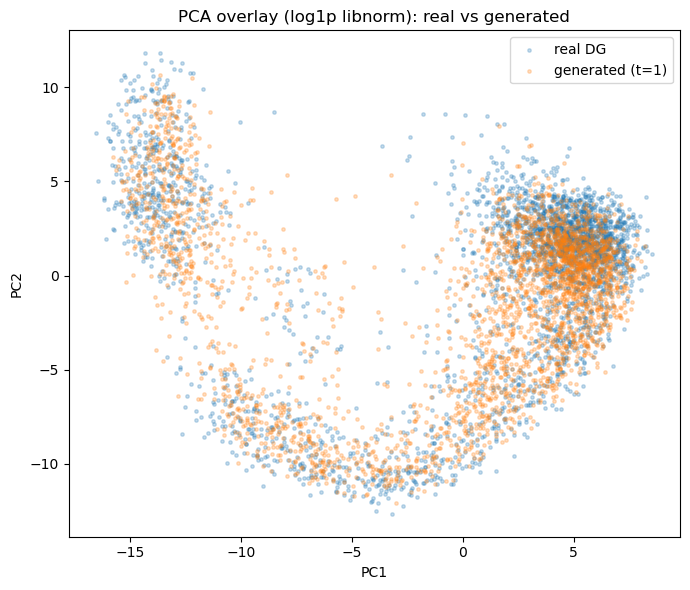

In [46]:
# Plot 1
plt.figure(figsize=(7, 6))
plt.scatter(real_2d[:, 0], real_2d[:, 1], s=6, alpha=0.25, label="real DG")
plt.scatter(fake_2d[:, 0], fake_2d[:, 1], s=6, alpha=0.25, label="generated (t=1)")
plt.title("PCA overlay (log1p libnorm): real vs generated")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

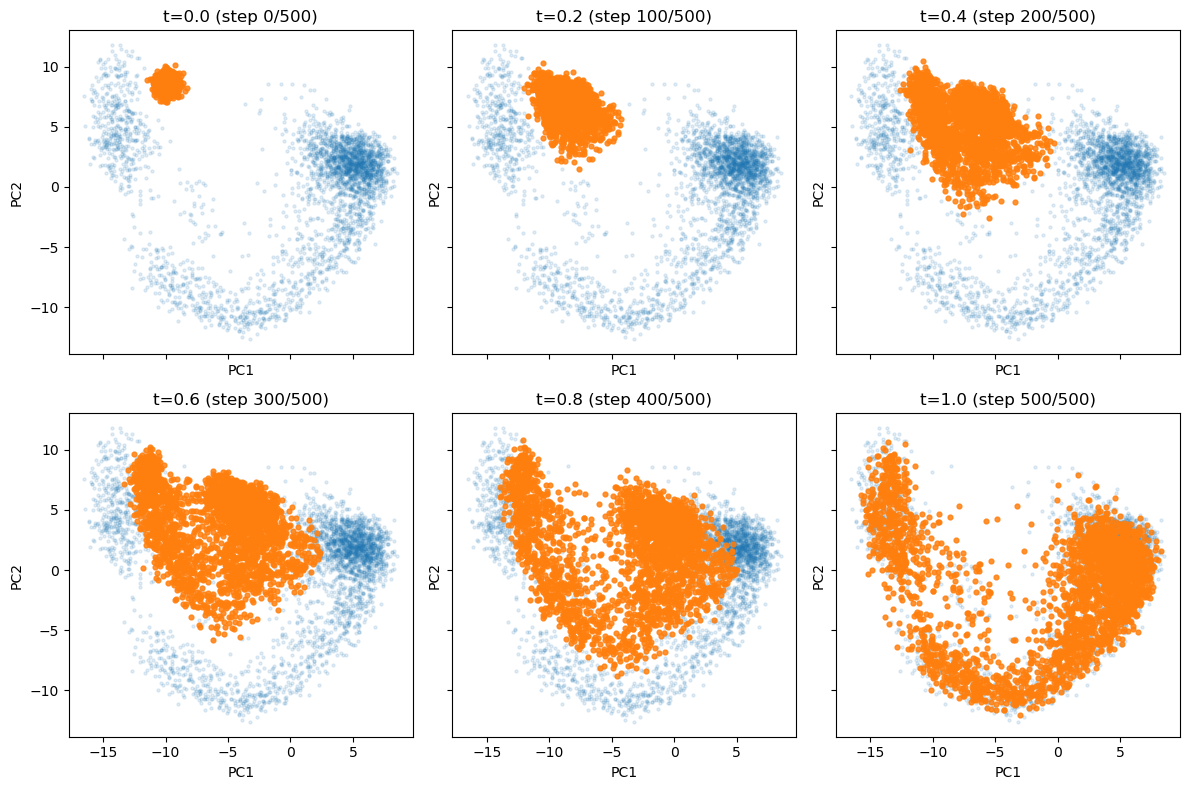

In [47]:
# Plot 2
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()
for j, ax in enumerate(axes):
    ax.scatter(real_2d[:, 0], real_2d[:, 1], s=5, alpha=0.12)
    ax.scatter(traj_snap_2d[j, :, 0], traj_snap_2d[j, :, 1], s=12, alpha=0.85)
    ax.set_title(f"t={t_show[j]:.1f} (step {snap_ids[j]}/{n_step_eval})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()